# Phase 4 — ARIA v7.0 多源遙測融合災害分析

**專案**：風雨夾擊：樺加沙颱風期間花蓮避難所的綜合風險評估  
**事件**：2025 年 9 月 21–23 日 樺加沙颱風 (Typhoon Krathon 2025)  
**方法**：整合 Sentinel-2 光學影像 + Sentinel-1 SAR 雷達，建構全天候多源融合災害監測

---
## 分析架構

| Phase | 說明 |
|-------|------|
| **4A** | Sentinel-2 STAC 搜尋 + TCI 預覽 |
| **4B** | 多波段載入（B02/B03/B04/B08/B11/B12）+ SCL 雲遮罩 |
| **4C** | NDVI / NDWI / BSI 指標計算 + Δ變化偵測 |
| **4D** | Sentinel-1 SAR 水體偵測（全天候） |
| **4E** | 多源融合（Optical × SAR 信心分級） |
| **4F** | 地形校正（DEM 坡度濾除假水體） |
| **4G** | 空間疊合：崩塌/水體遮罩 × 避難所風險 |
| **4H** | 最終視覺化輸出 + 成果摘要 |


## 0. 環境設定

In [2]:
# Cell 0-A: 安裝相依套件（僅首次執行）
# !pip install pystac-client stackstac rioxarray planetary-computer python-dotenv geopandas rasterio pyproj elevation


In [3]:
import os, warnings, time
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import rasterio
from rasterio.features import shapes
from scipy.ndimage import median_filter
import rioxarray as rxr
import xarray as xr
import stackstac
import pystac_client
import planetary_computer as pc
from shapely.geometry import shape, box
import pyproj

warnings.filterwarnings('ignore')

# ── 全域中文字體 ──────────────────────────────────────────────────────────────
import matplotlib
import matplotlib.font_manager as fm

_cjk = ['Noto Sans CJK TC','Noto Sans TC','Microsoft JhengHei',
        'Microsoft YaHei','PingFang TC','Heiti TC','WenQuanYi Micro Hei']
_avail = {f.name for f in fm.fontManager.ttflist}
_font  = next((f for f in _cjk if f in _avail), None)
if _font:
    matplotlib.rcParams['font.family'] = _font
    print(f'✅ 中文字體: {_font}')
else:
    _paths = [p for p in fm.findSystemFonts()
              if any(k in p.lower() for k in ['noto','cjk','jheng','yahei','pingfang','wqy'])]
    if _paths:
        fm.fontManager.addfont(_paths[0])
        matplotlib.rcParams['font.family'] = fm.FontProperties(fname=_paths[0]).get_name()
        print(f'✅ 中文字體（路徑）: {_paths[0]}')
    else:
        print('⚠️  找不到中文字體')
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 路徑設定 ──────────────────────────────────────────────────────────────────
DATA_DIR   = Path(r'C:\Users\user\CascadeProjects\final_project\data')
OUTPUT_DIR = Path(r'C:\Users\user\CascadeProjects\final_project\output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHELTER_CSV  = DATA_DIR / 'shelters_in_hualien.csv'
DEBRIS_SHP   = DATA_DIR / '114年度1745條土石流潛勢溪流圖' / 'debrisstream1745_20250105_twd97_UTF8.shp'
TOWNSHIP_SHP = DATA_DIR / '鄉(鎮、市、區)界線1140318' / 'TOWN_MOI_1140318.shp'

# ── 分析參數 ──────────────────────────────────────────────────────────────────
HUALIEN_BBOX  = [121.23, 23.13, 121.75, 24.31]  # [W, S, E, N]
TARGET_EPSG   = 32651                             # UTM Zone 51N
RESOLUTION    = 10                                # Sentinel-2 解析度 (m)
PIXEL_AREA_KM2 = (RESOLUTION / 1000) ** 2

PRE_WINDOW  = ('2025-09-05', '2025-09-19')  # 災前
POST_WINDOW = ('2025-09-25', '2025-10-15')  # 災後

# SCL 有效像素（保留類別）
VALID_SCL = [4, 5, 6, 7, 11]  # 植被/裸土/水體/低雲機率/雪

# 閾值
DNDVI_THRESH  = -0.2   # ΔNDVI < -0.2 → 植被破壞（崩塌）
DNDWI_THRESH  =  0.2   # ΔNDWI >  0.2 → 新增水體
SAR_FLOOD_DB  = -18.0  # SAR VV < -18 dB → 一般水體
SAR_TURB_DB   = -14.0  # SAR VV < -14 dB → 濁水/高含沙
SLOPE_MAX_DEG =  25.0  # 坡度 > 25° → 排除假水體

check = {'shelters_in_hualien.csv': SHELTER_CSV,
         'debris_stream.shp': DEBRIS_SHP,
         'township.shp': TOWNSHIP_SHP}
print('資料檔案確認:')
for name, p in check.items():
    print(f"  {'✅' if p.exists() else '❌'} {name}")
print(f'\n輸出目錄: {OUTPUT_DIR}')


✅ 中文字體: Microsoft JhengHei
資料檔案確認:
  ✅ shelters_in_hualien.csv
  ✅ debris_stream.shp
  ✅ township.shp

輸出目錄: C:\Users\user\CascadeProjects\final_project\output


---
## Phase 4A — Sentinel-2 STAC 搜尋 + TCI 預覽


In [4]:
# Cell 4A-1: 連線 Planetary Computer
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace
)
print(f'✅ 連線成功: {catalog.title}')


✅ 連線成功: Microsoft Planetary Computer STAC API


In [5]:
# Cell 4A-2: 搜尋函式（指數退避重試）
def robust_search(catalog, bbox, date_range, cloud_max=30, max_retries=4):
    for attempt in range(max_retries):
        try:
            items = list(catalog.search(
                collections=['sentinel-2-l2a'],
                bbox=bbox,
                datetime=f'{date_range[0]}/{date_range[1]}',
                max_items=10
            ).items())
            items = [i for i in items if i.properties.get('eo:cloud_cover', 100) < cloud_max]
            items.sort(key=lambda i: i.properties.get('eo:cloud_cover', 100))
            return items
        except Exception as e:
            wait = 2 ** attempt
            print(f'  第{attempt+1}次失敗: {e}，{wait}s 後重試...')
            time.sleep(wait)
    return []

print('搜尋 PRE...'); pre_items  = robust_search(catalog, HUALIEN_BBOX, PRE_WINDOW,  cloud_max=20)
print(f'  → {len(pre_items)} 個候選')
print('搜尋 POST...'); post_items = robust_search(catalog, HUALIEN_BBOX, POST_WINDOW, cloud_max=30)
print(f'  → {len(post_items)} 個候選')


搜尋 PRE...
  → 2 個候選
搜尋 POST...
  → 7 個候選


  💾 tci_candidates_pre.png


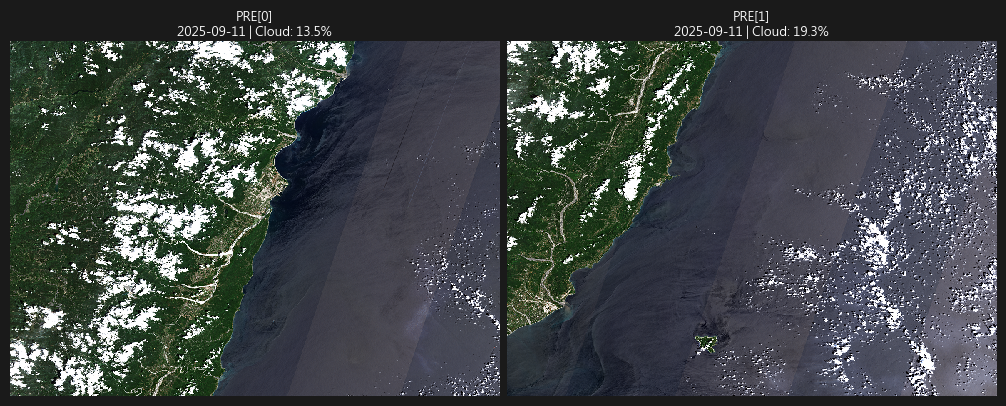

PRE 候選清單:
  [0] S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914  2025-09-11  雲量=13.519251
  [1] S2C_MSIL2A_20250911T022551_R046_T51QUF_20250911T055914  2025-09-11  雲量=19.274223
  💾 tci_candidates_post.png


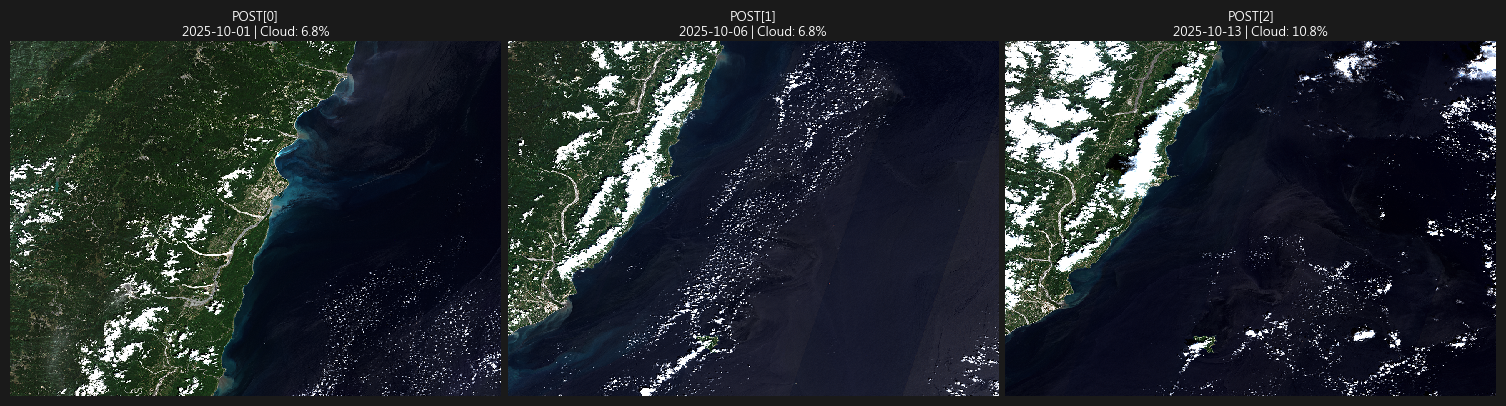

POST 候選清單:
  [0] S2C_MSIL2A_20251001T022551_R046_T51QUG_20251001T055313  2025-10-01  雲量=6.756122
  [1] S2B_MSIL2A_20251006T022529_R046_T51QUF_20251006T042653  2025-10-06  雲量=6.816862
  [2] S2A_MSIL2A_20251013T023141_R046_T51QUF_20251013T083919  2025-10-13  雲量=10.825604


In [6]:
# Cell 4A-3: TCI 預覽（黑底並排，仿附圖格式）
def preview_tci_panel(items, window_name, n=3, save_path=None):
    candidates = items[:n]
    if not candidates:
        print(f'⚠️  {window_name} 無候選影像'); return
    fig, axes = plt.subplots(1, len(candidates), figsize=(5*len(candidates), 4),
                              facecolor='#1a1a1a')
    if len(candidates) == 1: axes = [axes]
    for idx, (ax, item) in enumerate(zip(axes, candidates)):
        ax.set_facecolor('#1a1a1a')
        date  = item.properties.get('datetime','')[:10]
        cloud = item.properties.get('eo:cloud_cover','?')
        try:
            tci = rxr.open_rasterio(pc.sign(item).assets['visual'].href, overview_level=3)
            tci.plot.imshow(ax=ax)
        except Exception as e:
            ax.text(0.5,0.5,f'載入失敗\n{e}',ha='center',va='center',
                    transform=ax.transAxes,fontsize=8,color='red')
        try: cs = f'{float(cloud):.1f}%'
        except: cs = str(cloud)
        ax.set_title(f'{window_name}[{idx}]\n{date} | Cloud: {cs}',
                     fontsize=9, color='white', pad=4)
        ax.axis('off')
    fig.patch.set_facecolor('#1a1a1a')
    plt.tight_layout(pad=0.5)
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight', facecolor='#1a1a1a')
        print(f'  💾 {save_path.name}')
    plt.show(); plt.close()
    print(f'{window_name} 候選清單:')
    for i, it in enumerate(candidates):
        print(f"  [{i}] {it.id}  {it.properties.get('datetime','')[:10]}  雲量={it.properties.get('eo:cloud_cover','?')}")

preview_tci_panel(pre_items,  'PRE',  n=3, save_path=OUTPUT_DIR/'tci_candidates_pre.png')
preview_tci_panel(post_items, 'POST', n=3, save_path=OUTPUT_DIR/'tci_candidates_post.png')


In [7]:
# Cell 4A-4: 選定場景（依 TCI 預覽調整索引）
PRE_ITEM  = pre_items[0]   # ← 視 TCI 預覽修改
POST_ITEM = post_items[0]  # ← 視 TCI 預覽修改

pre_date   = PRE_ITEM.properties.get('datetime','')[:10]
post_date  = POST_ITEM.properties.get('datetime','')[:10]
pre_cloud  = PRE_ITEM.properties.get('eo:cloud_cover','?')
post_cloud = POST_ITEM.properties.get('eo:cloud_cover','?')
all_items  = pre_items + post_items

print(f'✅ PRE   {pre_date}  雲量={pre_cloud}%  {PRE_ITEM.id}')
print(f'✅ POST  {post_date}  雲量={post_cloud}%  {POST_ITEM.id}')


✅ PRE   2025-09-11  雲量=13.519251%  S2C_MSIL2A_20250911T022551_R046_T51QUG_20250911T055914
✅ POST  2025-10-01  雲量=6.756122%  S2C_MSIL2A_20251001T022551_R046_T51QUG_20251001T055313


---
## Phase 4B — 多波段載入（B02/B03/B04/B08/B11/B12）+ SCL 雲遮罩

載入所有指標所需波段，並用 SCL 像素級雲遮罩濾除雲/陰影。

| 波段 | 用途 |
|------|------|
| B04 (Red) + B08 (NIR) | NDVI |
| B03 (Green) + B08 (NIR) | NDWI |
| B04 (Red) + B08 (NIR) + B11 (SWIR) | BSI |
| SCL | 雲遮罩（像素級） |


In [8]:
# Cell 4B-1: GDAL 重試設定
os.environ['GDAL_HTTP_MAX_RETRY']  = '5'
os.environ['GDAL_HTTP_RETRY_DELAY'] = '2'

REFLECT_BANDS = ['B02', 'B03', 'B04', 'B08', 'B11', 'B12']

def load_s2(item, bbox=HUALIEN_BBOX, epsg=TARGET_EPSG):
    signed = pc.sign(item)

    # ── 反射率波段（統一 10m） ────────────────────────────────────────────────
    reflect = stackstac.stack(
        [signed], assets=REFLECT_BANDS,
        epsg=epsg, resolution=RESOLUTION,
        bounds_latlon=bbox, chunksize=2048,
    ).squeeze('time')
    reflect = (reflect / 10000.0).astype('float32')

    # ── SCL：與反射率完全相同的 epsg/resolution/bounds ───────────────────────
    # 關鍵：讓 stackstac 自行把 SCL 從 20m reproject 到 10m 格柵
    # 使用 resampling='nearest' 保持整數類別值不失真
    scl_cube = stackstac.stack(
        [signed], assets=['SCL'],
        epsg=epsg,
        resolution=RESOLUTION,          # 同樣 10m，stackstac 自動 resample
        bounds_latlon=bbox,
        chunksize=2048,
        resampling=rasterio.enums.Resampling.nearest,   # 保持整數類別
    ).squeeze('time').squeeze('band')
    scl = scl_cube.compute().values.astype('int16')

    # ── 驗證對齊 ─────────────────────────────────────────────────────────────
    ref_shape = reflect.sel(band='B04').compute().values.shape
    if scl.shape != ref_shape:
        # 理論上 stackstac 相同參數不應發生，但防禦性裁切/補邊
        print(f'  ⚠️  SCL shape {scl.shape} != 反射率 {ref_shape}，強制對齊')
        scl = scl[:ref_shape[0], :ref_shape[1]]
        if scl.shape != ref_shape:
            py = ref_shape[0] - scl.shape[0]
            px = ref_shape[1] - scl.shape[1]
            scl = np.pad(scl, ((0, py), (0, px)), mode='edge')
    else:
        print(f'  ✅ SCL 與反射率完全對齊 {scl.shape}')

    valid_mask = np.isin(scl, VALID_SCL)
    masked_pct = (~valid_mask).mean() * 100

    return reflect, scl, valid_mask, masked_pct

print('載入 PRE...')
pre_reflect,  pre_scl,  pre_mask,  pre_masked_pct  = load_s2(PRE_ITEM)
print(f'  stack shape={pre_reflect.sizes}  SCL遮罩={pre_masked_pct:.1f}%')

print('載入 POST...')
post_reflect, post_scl, post_mask, post_masked_pct = load_s2(POST_ITEM)
print(f'  stack shape={post_reflect.sizes}  SCL遮罩={post_masked_pct:.1f}%')

print('✅ 多波段載入完成（SCL 與反射率完全對齊）')


載入 PRE...
  ✅ SCL 與反射率完全對齊 (13125, 5441)
  stack shape=Frozen({'band': 6, 'y': 13125, 'x': 5441})  SCL遮罩=39.7%
載入 POST...
  ✅ SCL 與反射率完全對齊 (13125, 5441)
  stack shape=Frozen({'band': 6, 'y': 13125, 'x': 5441})  SCL遮罩=29.7%
✅ 多波段載入完成（SCL 與反射率完全對齊）


In [9]:
# Cell 4B-2: 擷取各波段陣列（套 SCL 遮罩 → NaN）
def get_masked(reflect, mask, band):
    arr = reflect.sel(band=band).compute().values.astype('float32')
    return np.where(mask, arr, np.nan)

pre_B02  = get_masked(pre_reflect,  pre_mask,  'B02')
pre_B03  = get_masked(pre_reflect,  pre_mask,  'B03')
pre_B04  = get_masked(pre_reflect,  pre_mask,  'B04')
pre_B08  = get_masked(pre_reflect,  pre_mask,  'B08')
pre_B11  = get_masked(pre_reflect,  pre_mask,  'B11')
pre_B12  = get_masked(pre_reflect,  pre_mask,  'B12')

post_B02 = get_masked(post_reflect, post_mask, 'B02')
post_B03 = get_masked(post_reflect, post_mask, 'B03')
post_B04 = get_masked(post_reflect, post_mask, 'B04')
post_B08 = get_masked(post_reflect, post_mask, 'B08')
post_B11 = get_masked(post_reflect, post_mask, 'B11')
post_B12 = get_masked(post_reflect, post_mask, 'B12')

print('✅ 波段擷取完成（SCL 遮罩已套用，雲/陰影像素 = NaN）')
print(f'  shape: {pre_B04.shape}')

# SCL 分類分佈
SCL_LABELS = {0:'無資料',1:'飽和',2:'深陰影',3:'雲陰影',4:'植被',
              5:'裸土',6:'水體',7:'低雲',8:'中雲',9:'高雲',10:'卷雲',11:'雪'}
print('\nSCL 分佈 (PRE):')
for v, c in sorted(zip(*np.unique(pre_scl, return_counts=True)), key=lambda x: -x[1])[:6]:
    print(f"  {int(v):2d} {SCL_LABELS.get(int(v),'?'):8s}  {c/pre_scl.size*100:5.1f}%")


✅ 波段擷取完成（SCL 遮罩已套用，雲/陰影像素 = NaN）
  shape: (13125, 5441)

SCL 分佈 (PRE):
   4 植被         34.8%
   0 無資料        24.2%
   6 水體         21.8%
   9 高雲          7.3%
   8 中雲          4.8%
   5 裸土          3.4%


---
## Phase 4C — 遙測指標計算（NDVI / NDWI / BSI）+ 變化偵測

| 指標 | 公式 | 災害意義 |
|------|------|---------|
| NDVI | (NIR−Red)/(NIR+Red) | 植被狀態；ΔNDVI < −0.2 → 崩塌 |
| NDWI | (Green−NIR)/(Green+NIR) | 水體；ΔNDWI > 0.2 → 新增淹水 |
| BSI | ((Red+SWIR1)−(NIR+Blue))/((Red+SWIR1)+(NIR+Blue)) | 裸露土壤 |


In [10]:
# Cell 4C-1: 計算三項指標
def safe_index(a, b):
    denom = a + b
    return np.where(np.abs(denom) > 1e-9, (a - b) / denom, np.nan).astype('float32')

# NDVI
ndvi_pre  = safe_index(pre_B08,  pre_B04)
ndvi_post = safe_index(post_B08, post_B04)

# NDWI (Green-based, McFeeters)
ndwi_pre  = safe_index(pre_B03,  pre_B08)
ndwi_post = safe_index(post_B03, post_B08)

# BSI
bsi_pre   = safe_index(pre_B04  + pre_B11,  pre_B08  + pre_B02)
bsi_post  = safe_index(post_B04 + post_B11, post_B08 + post_B02)

print('✅ NDVI / NDWI / BSI 計算完成')
for name, pre, post in [('NDVI', ndvi_pre, ndvi_post),
                         ('NDWI', ndwi_pre, ndwi_post),
                         ('BSI',  bsi_pre,  bsi_post)]:
    print(f'  {name}  PRE mean={np.nanmean(pre):.3f}  POST mean={np.nanmean(post):.3f}')


✅ NDVI / NDWI / BSI 計算完成
  NDVI  PRE mean=0.313  POST mean=0.338
  NDWI  PRE mean=-0.271  POST mean=-0.288
  BSI  PRE mean=-0.104  POST mean=-0.122


In [11]:
# Cell 4C-2: 計算差值（Δ變化量）
delta_ndvi = ndvi_post - ndvi_pre   # 負值 = 植被消失（與文件定義一致）
delta_ndwi = ndwi_post - ndwi_pre   # 正值 = 新增水體

print('ΔNDVI 統計（災後−災前，負值=植被消失）:')
for p in [5,25,50,75,95]:
    print(f'  p{p:2d} = {np.nanpercentile(delta_ndvi, p):.3f}')

print('\nΔNDWI 統計:')
for p in [5,25,50,75,95]:
    print(f'  p{p:2d} = {np.nanpercentile(delta_ndwi, p):.3f}')


ΔNDVI 統計（災後−災前，負值=植被消失）:
  p 5 = -0.066
  p25 = -0.014
  p50 = 0.001
  p75 = 0.016
  p95 = 0.080

ΔNDWI 統計:
  p 5 = -0.073
  p25 = -0.013
  p50 = 0.002
  p75 = 0.020
  p95 = 0.102


✅ 崩塌潛勢遮罩  (ΔNDVI < -0.2):  45.163 km²
✅ 光學水體遮罩  (ΔNDWI >  0.2):  60.797 km²


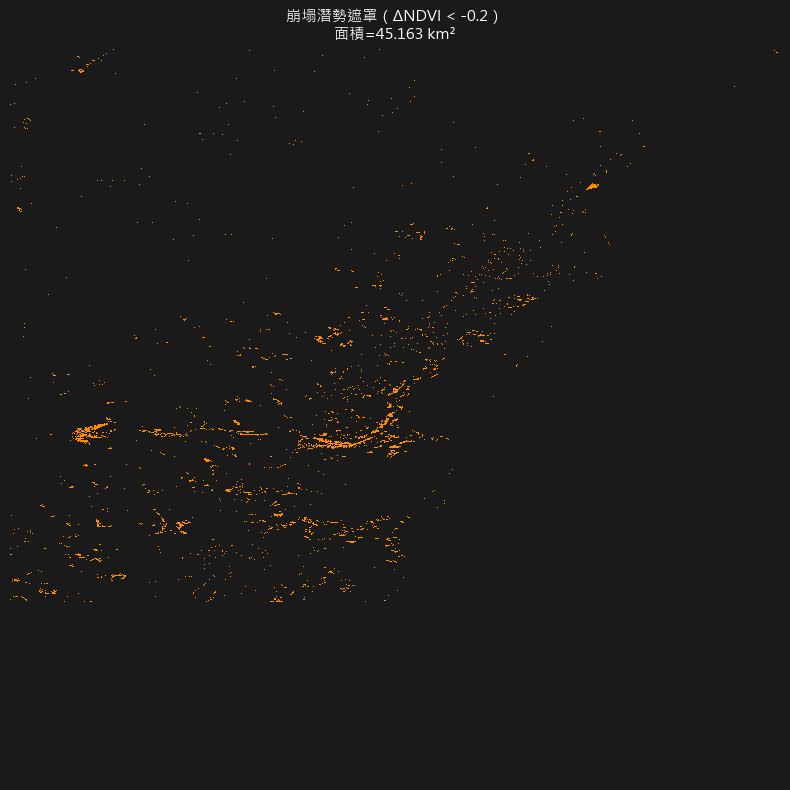

✅ 崩塌遮罩圖已儲存: landslide_mask.png


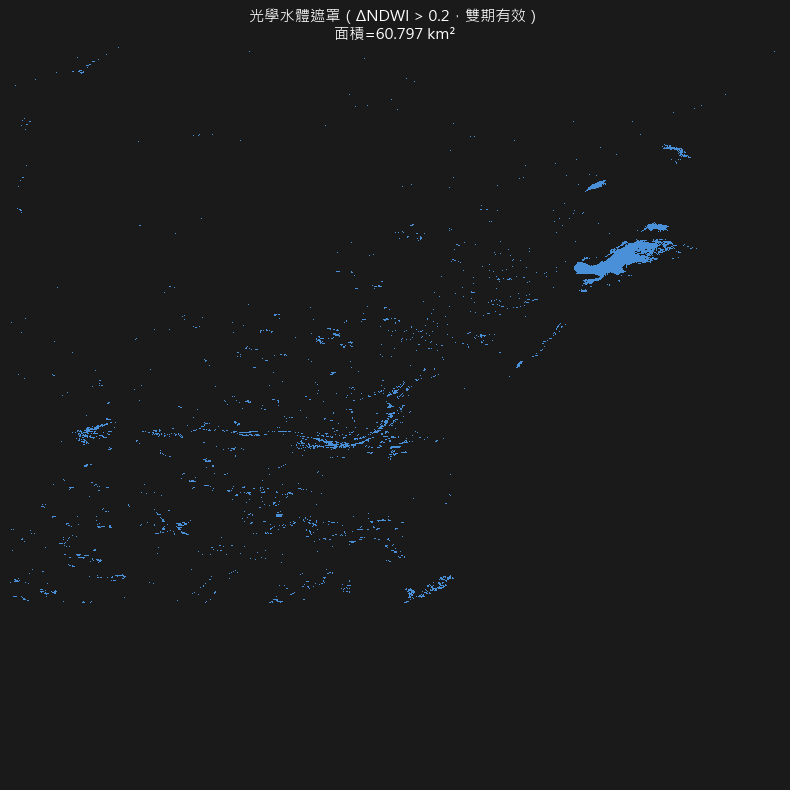

✅ 光學水體遮罩圖已儲存: optical_water_mask.png


In [12]:
# Cell 4C-3: 災害遮罩 + 視覺化輸出

# ── 崩塌遮罩：ΔNDVI < -0.2 ──────────────────────────────────────────────────
landslide_mask = (delta_ndvi < DNDVI_THRESH).astype(np.uint8)
landslide_area = landslide_mask.sum() * PIXEL_AREA_KM2

# ── 光學水體遮罩：ΔNDWI > 0.2 且兩期都有有效像素（排除單側 NaN 造成的假水體）
both_valid_ndwi = (~np.isnan(ndwi_pre)) & (~np.isnan(ndwi_post))
optical_water_mask = (
    (delta_ndwi > DNDWI_THRESH) & both_valid_ndwi
).astype(np.uint8)
optical_water_area = optical_water_mask.sum() * PIXEL_AREA_KM2

print(f'✅ 崩塌潛勢遮罩  (ΔNDVI < {DNDVI_THRESH}):  {landslide_area:.3f} km²')
print(f'✅ 光學水體遮罩  (ΔNDWI >  {DNDWI_THRESH}):  {optical_water_area:.3f} km²')

# ── 視覺化：崩塌遮罩 ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
ax.imshow(landslide_mask,
          cmap=mcolors.ListedColormap(['#1a1a1a', '#FF8C00']),
          vmin=0, vmax=1, aspect='auto', interpolation='none')
ax.set_title(f'崩塌潛勢遮罩（ΔNDVI < {DNDVI_THRESH}）\n面積={landslide_area:.3f} km²',
             fontsize=11, color='white', pad=6)
ax.axis('off')
fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'landslide_mask.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show(); plt.close()
print('✅ 崩塌遮罩圖已儲存: landslide_mask.png')

# ── 視覺化：光學水體遮罩 ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')
ax.imshow(optical_water_mask,
          cmap=mcolors.ListedColormap(['#1a1a1a', '#4A90D9']),
          vmin=0, vmax=1, aspect='auto', interpolation='none')
ax.set_title(f'光學水體遮罩（ΔNDWI > {DNDWI_THRESH}，雙期有效）\n面積={optical_water_area:.3f} km²',
             fontsize=11, color='white', pad=6)
ax.axis('off')
fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'optical_water_mask.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show(); plt.close()
print('✅ 光學水體遮罩圖已儲存: optical_water_mask.png')

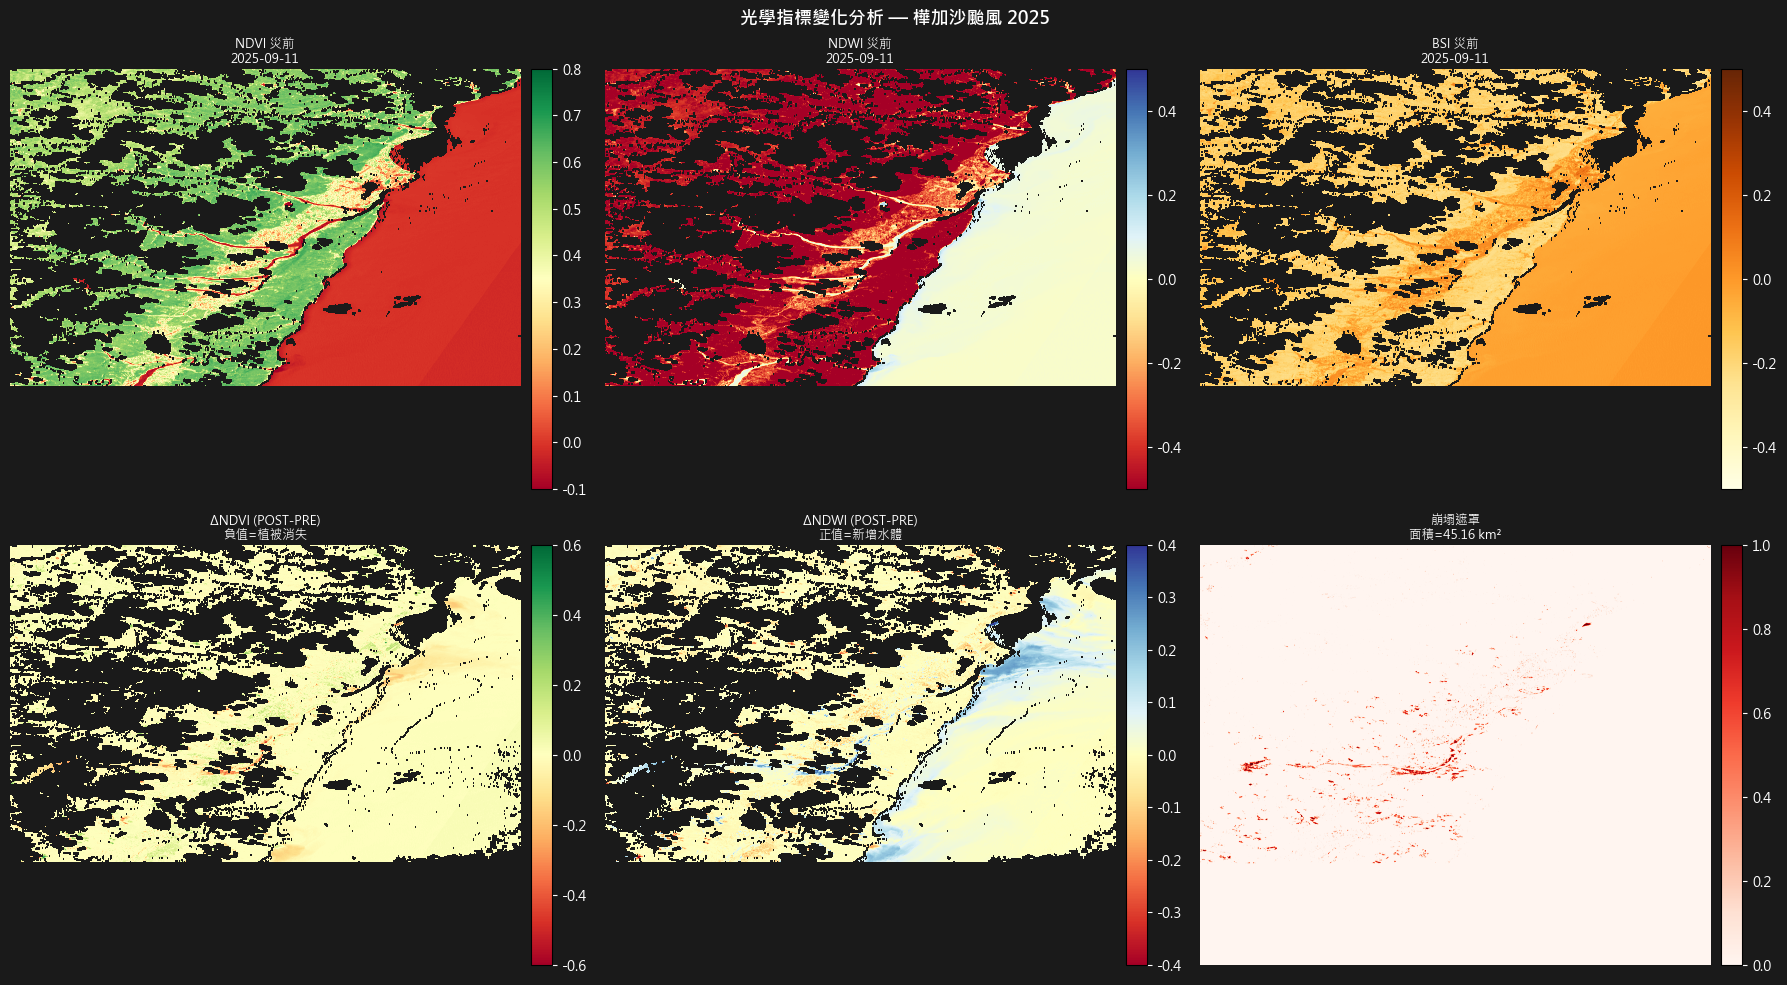

✅ 光學指標面板已儲存


In [13]:
# Cell 4C-4: 視覺化指標變化（3×2 面板）
fig, axes = plt.subplots(2, 3, figsize=(18, 10), facecolor='#1a1a1a')

panels = [
    (ndvi_pre,         f'NDVI 災前\n{pre_date}',   'RdYlGn', -0.1,  0.8),
    (ndwi_pre,         f'NDWI 災前\n{pre_date}',   'RdYlBu', -0.5,  0.5),
    (bsi_pre,          f'BSI 災前\n{pre_date}',    'YlOrBr', -0.5,  0.5),
    (delta_ndvi,       f'ΔNDVI (POST-PRE)\n負值=植被消失', 'RdYlGn',  -0.6, 0.6),
    (delta_ndwi,       f'ΔNDWI (POST-PRE)\n正值=新增水體', 'RdYlBu',  -0.4, 0.4),
    (landslide_mask,   f'崩塌遮罩\n面積={landslide_area:.2f} km²', 'Reds', 0, 1),
]
for ax, (data, title, cmap, vmin, vmax) in zip(axes.flat, panels):
    ax.set_facecolor('#1a1a1a')
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(title, fontsize=9, color='white', pad=4)
    ax.axis('off')
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cb.ax.yaxis.set_tick_params(color='white')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')

fig.patch.set_facecolor('#1a1a1a')
plt.suptitle('光學指標變化分析 — 樺加沙颱風 2025', fontsize=13,
             fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'optical_change_panel.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show(); plt.close()
print('✅ 光學指標面板已儲存')


---
## Phase 4D — Sentinel-1 SAR 雷達水體偵測（全天候）

颱風期間雲覆蓋率達 80–90%，光學影像失效。SAR 可穿透雲層，提供全天候地表觀測。

- **VV 極化**：對水體（低後向散射）最敏感
- **中值濾波**：降低 speckle noise
- **閾值分割**：−18 dB（一般水體）/ −14 dB（濁水）


In [14]:
# Cell 4D-1: 搜尋 Sentinel-1 SAR 影像（災前 / 災後，與光學相同時間窗口）
# SAR 單景可能無法完整覆蓋花蓮，因此搜尋多景並印出覆蓋範圍供確認

s1_catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=pc.sign_inplace
)

SAR_PRE_WINDOW  = PRE_WINDOW
SAR_POST_WINDOW = POST_WINDOW

def search_s1(start, end, label='', max_retries=4):
    for attempt in range(max_retries):
        try:
            for collection in ['sentinel-1-rtc', 'sentinel-1-grd']:
                items = list(s1_catalog.search(
                    collections=[collection],
                    bbox=HUALIEN_BBOX,
                    datetime=f'{start}/{end}',
                    max_items=10   # 多取幾景，確保有足夠覆蓋
                ).items())
                if items:
                    items.sort(key=lambda x: x.datetime)
                    print(f'  [{label}] {collection}: {len(items)} 筆')
                    for it in items:
                        bbox_it = it.bbox  # [W,S,E,N]
                        print(f"    {it.datetime.strftime('%Y-%m-%d')}  "
                              f"bbox=[{bbox_it[0]:.2f},{bbox_it[1]:.2f},"
                              f"{bbox_it[2]:.2f},{bbox_it[3]:.2f}]  {it.id}")
                    return items, collection
            print(f'  [{label}] 找不到任何 Sentinel-1 影像')
            return [], None
        except Exception as e:
            wait = 2 ** attempt
            print(f'  第{attempt+1}次失敗: {e}，{wait}s 後重試...')
            time.sleep(wait)
    return [], None

print('搜尋 SAR PRE...')
sar_pre_items,  sar_col = search_s1(*SAR_PRE_WINDOW,  label='PRE')
print('\n搜尋 SAR POST...')
sar_post_items, _       = search_s1(*SAR_POST_WINDOW, label='POST')

# ── 選景邏輯：優先選覆蓋 HUALIEN_BBOX 最完整的景 ─────────────────────────────
def coverage_score(item, target_bbox):
    ib = item.bbox
    # 計算交集面積 / 目標面積
    ix1 = max(ib[0], target_bbox[0]); iy1 = max(ib[1], target_bbox[1])
    ix2 = min(ib[2], target_bbox[2]); iy2 = min(ib[3], target_bbox[3])
    if ix2 <= ix1 or iy2 <= iy1: return 0.0
    inter = (ix2-ix1) * (iy2-iy1)
    total = (target_bbox[2]-target_bbox[0]) * (target_bbox[3]-target_bbox[1])
    return inter / total

if sar_pre_items:
    sar_pre_items_scored = sorted(sar_pre_items,
                                   key=lambda x: coverage_score(x, HUALIEN_BBOX),
                                   reverse=True)
    sar_pre_item = sar_pre_items_scored[0]
    print(f'\n選定 SAR PRE: {sar_pre_item.datetime.strftime("%Y-%m-%d")}  '
          f'覆蓋率={coverage_score(sar_pre_item, HUALIEN_BBOX)*100:.1f}%')
else:
    sar_pre_item = None

if sar_post_items:
    sar_post_items_scored = sorted(sar_post_items,
                                    key=lambda x: coverage_score(x, HUALIEN_BBOX),
                                    reverse=True)
    sar_post_item = sar_post_items_scored[0]
    print(f'選定 SAR POST: {sar_post_item.datetime.strftime("%Y-%m-%d")}  '
          f'覆蓋率={coverage_score(sar_post_item, HUALIEN_BBOX)*100:.1f}%')
    cov = coverage_score(sar_post_item, HUALIEN_BBOX)
    if cov < 0.9:
        print(f'\n⚠️  POST 覆蓋率僅 {cov*100:.1f}%，未完整覆蓋花蓮縣')
        print('   未覆蓋區域在 fusion 圖中將標記為 NaN（排除在分析之外）')
        print('   若需完整覆蓋，可調整 SAR_POST_WINDOW 延長搜尋時間')
else:
    sar_post_item = None

SAR_AVAILABLE = (sar_pre_item is not None) and (sar_post_item is not None)
if not SAR_AVAILABLE:
    print('\n⚠️  SAR 影像不足，Phase 4E 融合將僅使用光學結果')


搜尋 SAR PRE...
  [PRE] sentinel-1-rtc: 8 筆
    2025-09-06  bbox=[120.10,21.43,122.83,23.60]  S1A_IW_GRDH_1SDV_20250906T100054_20250906T100123_060866_07944A_rtc
    2025-09-06  bbox=[119.78,23.18,122.52,25.10]  S1A_IW_GRDH_1SDV_20250906T100123_20250906T100148_060866_07944A_rtc
    2025-09-08  bbox=[119.64,23.85,122.44,25.89]  S1A_IW_GRDH_1SDV_20250908T215221_20250908T215250_060902_0795B8_rtc
    2025-09-08  bbox=[119.35,22.34,122.07,24.27]  S1A_IW_GRDH_1SDV_20250908T215250_20250908T215315_060902_0795B8_rtc
    2025-09-14  bbox=[119.60,23.67,122.41,25.73]  S1C_IW_GRDH_1SDV_20250914T215121_20250914T215150_004126_008331_rtc
    2025-09-14  bbox=[119.31,22.16,122.03,24.09]  S1C_IW_GRDH_1SDV_20250914T215150_20250914T215215_004126_008331_rtc
    2025-09-18  bbox=[120.10,21.43,122.83,23.60]  S1A_IW_GRDH_1SDV_20250918T100054_20250918T100123_061041_079B51_rtc
    2025-09-18  bbox=[119.78,23.18,122.52,25.10]  S1A_IW_GRDH_1SDV_20250918T100123_20250918T100148_061041_079B51_rtc

搜尋 SAR POST...
  [POS

In [15]:
# Cell 4D-2: 載入 SAR VV 波段（PRE + POST）+ 中值濾波
# 無資料區（SAR 未覆蓋）保留為 NaN，不參與後續融合分析

def load_sar_vv(item, bbox=HUALIEN_BBOX, epsg=TARGET_EPSG):
    signed = pc.sign(item)
    vv_key = next((k for k in signed.assets
                   if k.lower() in ['vv', 'vh'] or 'vv' in k.lower()), None)
    if vv_key is None:
        raise ValueError(f'找不到 VV 波段，可用: {list(signed.assets.keys())}')

    cube = stackstac.stack(
        [signed], assets=[vv_key],
        epsg=epsg,
        resolution=RESOLUTION,
        bounds_latlon=bbox,
        chunksize=2048,
        resampling=rasterio.enums.Resampling.bilinear,
        fill_value=np.nan,      # 未覆蓋區域填 NaN
    ).squeeze('time').squeeze('band')
    vv = cube.compute().values.astype('float32')

    # 線性 → dB（stackstac 有時回傳線性值）
    vv_db = np.where(
        (vv > 0) & (vv < 1e6),
        10 * np.log10(np.where(vv > 0, vv, np.nan)),
        vv   # 已是 dB（負值）
    )
    # < -50 或 > 10 視為無效
    vv_db = np.where((vv_db < -50) | (vv_db > 10), np.nan, vv_db)

    # 中值濾波（保留 NaN 位置）
    nan_mask = np.isnan(vv_db)
    filled   = np.nan_to_num(vv_db, nan=np.nanmedian(vv_db))
    filtered = median_filter(filled, size=3)
    vv_db    = np.where(nan_mask, np.nan, filtered)

    # 統計覆蓋率
    valid_pct = (~nan_mask).mean() * 100
    return vv_db, valid_pct

if SAR_AVAILABLE:
    print(f'載入 SAR PRE  ({sar_pre_item.datetime.strftime("%Y-%m-%d")})...')
    try:
        sar_pre_vv, pre_cov  = load_sar_vv(sar_pre_item)
        print(f'  ✅ shape={sar_pre_vv.shape}  覆蓋={pre_cov:.1f}%  '
              f'mean={np.nanmean(sar_pre_vv):.1f} dB')
    except Exception as e:
        print(f'  ❌ {e}'); sar_pre_vv = None; SAR_AVAILABLE = False

    if SAR_AVAILABLE:
        print(f'載入 SAR POST ({sar_post_item.datetime.strftime("%Y-%m-%d")})...')
        try:
            sar_post_vv, post_cov = load_sar_vv(sar_post_item)
            print(f'  ✅ shape={sar_post_vv.shape}  覆蓋={post_cov:.1f}%  '
                  f'mean={np.nanmean(sar_post_vv):.1f} dB')
            if post_cov < 90:
                print(f'  ⚠️  POST 覆蓋率 {post_cov:.1f}% < 90%')
                print('      未覆蓋區域（NaN）在 fusion 圖中將顯示為「無 SAR 資料」')
        except Exception as e:
            print(f'  ❌ {e}'); sar_post_vv = None; SAR_AVAILABLE = False

if not SAR_AVAILABLE:
    sar_pre_vv = None; sar_post_vv = None
    print('⚠️  SAR 載入失敗')


載入 SAR PRE  (2025-09-08)...
  ✅ shape=(13125, 5441)  覆蓋=69.8%  mean=-18.4 dB
載入 SAR POST (2025-10-02)...
  ✅ shape=(13125, 5441)  覆蓋=69.9%  mean=-18.5 dB
  ⚠️  POST 覆蓋率 69.9% < 90%
      未覆蓋區域（NaN）在 fusion 圖中將顯示為「無 SAR 資料」


✅ SAR 差值淹水偵測 (ΔSAR_VV < -3.0 dB):
   新增淹水面積: 279.434 km²
   無資料區域:   30.2%（SAR 未覆蓋，不參與融合）


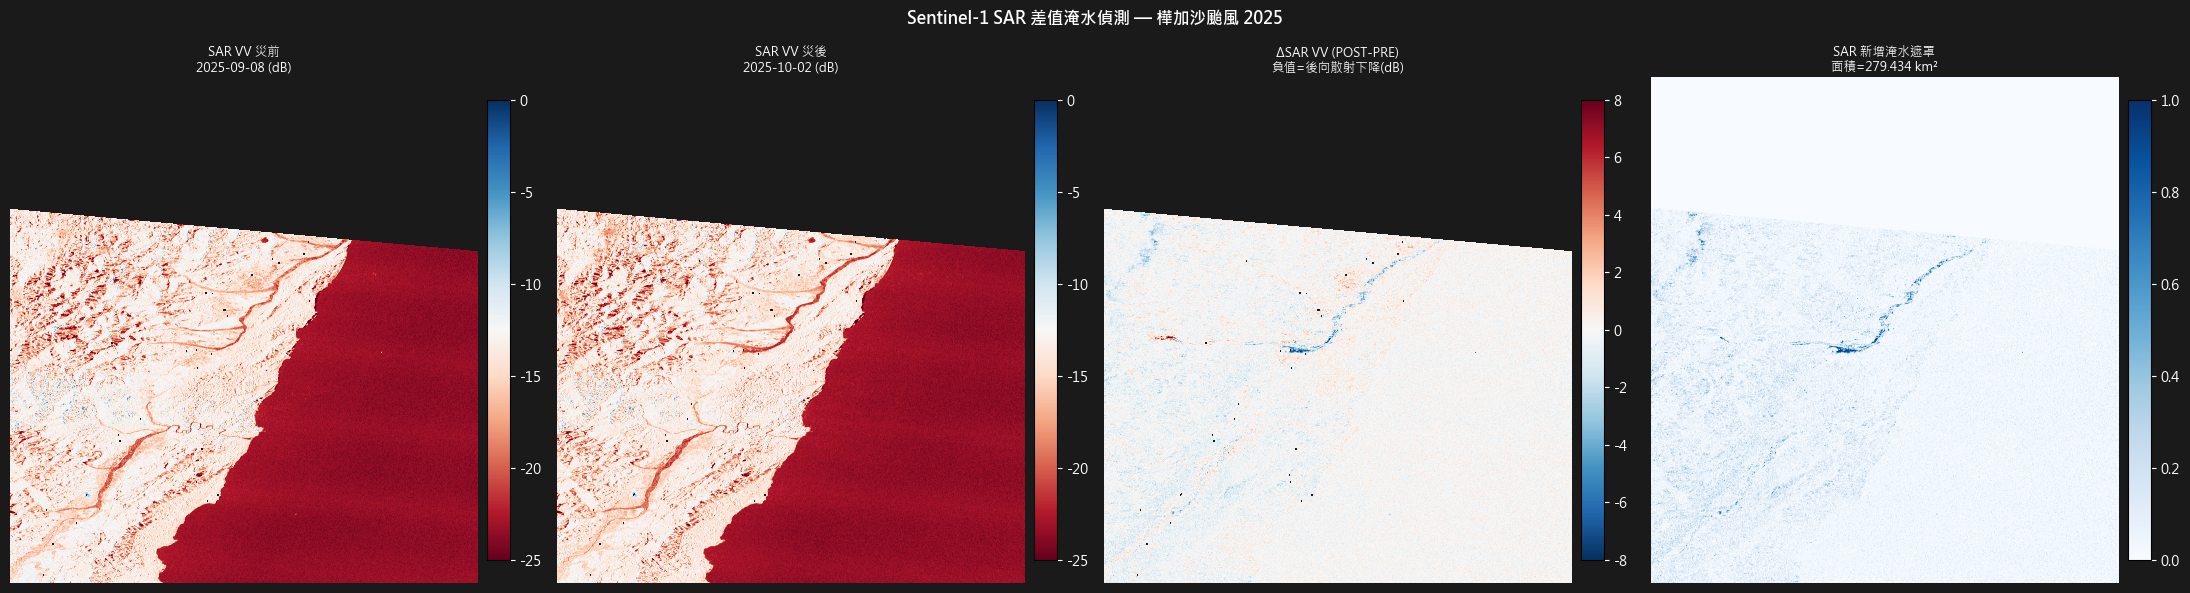

✅ SAR 淹水圖已儲存


In [16]:
# Cell 4D-3: SAR 差值計算 → 新增淹水偵測
# NaN（SAR 未覆蓋區域）→ 不納入遮罩，fusion 中標記為「無 SAR 資料」

if SAR_AVAILABLE and sar_pre_vv is not None and sar_post_vv is not None:
    h = min(sar_pre_vv.shape[0], sar_post_vv.shape[0])
    w = min(sar_pre_vv.shape[1], sar_post_vv.shape[1])
    sar_pre_vv  = sar_pre_vv[:h,  :w]
    sar_post_vv = sar_post_vv[:h, :w]

    # 差值（僅在兩景都有資料的區域計算）
    sar_both_valid = (~np.isnan(sar_pre_vv)) & (~np.isnan(sar_post_vv))
    sar_delta_vv   = np.where(sar_both_valid,
                               sar_post_vv - sar_pre_vv, np.nan)

    SAR_DELTA_THRESH = -3.0  # dB

    # 淹水遮罩：差值顯著下降 且 兩景都有資料
    sar_flood_mask  = np.where(
        sar_both_valid & (sar_delta_vv < SAR_DELTA_THRESH), 1, 0
    ).astype(np.uint8)
    # NaN 區域單獨記錄（fusion 時使用）
    sar_nodata_mask = (~sar_both_valid).astype(np.uint8)

    sar_flood_area = sar_flood_mask.sum() * PIXEL_AREA_KM2
    sar_nodata_pct = sar_nodata_mask.mean() * 100

    sar_pre_date  = sar_pre_item.datetime.strftime('%Y-%m-%d')
    sar_post_date = sar_post_item.datetime.strftime('%Y-%m-%d')

    print(f'✅ SAR 差值淹水偵測 (ΔSAR_VV < {SAR_DELTA_THRESH} dB):')
    print(f'   新增淹水面積: {sar_flood_area:.3f} km²')
    print(f'   無資料區域:   {sar_nodata_pct:.1f}%（SAR 未覆蓋，不參與融合）')

    # ── 視覺化 ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 4, figsize=(22, 6), facecolor='#1a1a1a')
    panels = [
        (sar_pre_vv,    f'SAR VV 災前\n{sar_pre_date} (dB)',        'RdBu',   -25,  0),
        (sar_post_vv,   f'SAR VV 災後\n{sar_post_date} (dB)',       'RdBu',   -25,  0),
        (sar_delta_vv,  'ΔSAR VV (POST-PRE)\n負值=後向散射下降(dB)','RdBu_r',  -8,  8),
        (sar_flood_mask,f'SAR 新增淹水遮罩\n面積={sar_flood_area:.3f} km²', 'Blues', 0, 1),
    ]
    for ax, (data, title, cmap, vmin, vmax) in zip(axes, panels):
        ax.set_facecolor('#1a1a1a')
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_title(title, fontsize=9, color='white', pad=4)
        ax.axis('off')
        cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cb.ax.yaxis.set_tick_params(color='white')
        plt.setp(cb.ax.yaxis.get_ticklabels(), color='white')
    fig.patch.set_facecolor('#1a1a1a')
    plt.suptitle('Sentinel-1 SAR 差值淹水偵測 — 樺加沙颱風 2025',
                 fontsize=12, fontweight='bold', color='white')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sar_flood_detection.png',
                dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
    plt.show(); plt.close()
    print('✅ SAR 淹水圖已儲存')

else:
    print('⏭️  跳過 SAR（無資料）')
    ref_shape      = optical_water_mask.shape
    sar_flood_mask = np.zeros(ref_shape, dtype=np.uint8)
    sar_nodata_mask= np.ones(ref_shape,  dtype=np.uint8)  # 全部標為無資料
    sar_flood_area = 0.0; sar_delta_vv = None
    sar_pre_date = ''; sar_post_date = ''


---
## Phase 4E — 多源資料融合（Optical × SAR 信心分級）

| 類別 | 條件 | 意義 |
|------|------|------|
| **High Confidence** (3) | 光學水體 + SAR 水體 | 雙重證據確認 |
| **SAR-only** (2) | 雲遮罩區 + SAR 水體 | 雷達補充光學盲區 |
| **Optical-only** (1) | 光學水體 + SAR 非水體 | 需人工檢查 |
| **No Detection** (0) | 無水體訊號 | 無災害 |


In [17]:
# Cell 4E-1: 光學 × SAR 淹水疊合分析（五分類，含 SAR 無資料區）
# 1 = 光學+SAR  High Confidence
# 2 = 僅光學    Optical-only
# 3 = 僅SAR     SAR-only
# 0 = 皆無      No Detection
# 9 = SAR 無資料（未覆蓋），不參與分析
# ── 載入避難所（需在 fusion 之前） ───────────────────────────────────────────
df_shelter = pd.read_csv(SHELTER_CSV, encoding='utf-8-sig')
shelters = gpd.GeoDataFrame(
    df_shelter,
    geometry=gpd.points_from_xy(df_shelter['經度'], df_shelter['緯度']),
    crs='EPSG:4326'
).to_crs(f'EPSG:{TARGET_EPSG}')
print(f'✅ 避難所: {len(shelters)} 筆')
ref_shape = optical_water_mask.shape

def align_to(src, target_shape):
    if src.shape == target_shape: return src
    out = src[:target_shape[0], :target_shape[1]]
    if out.shape != target_shape:
        py = target_shape[0] - out.shape[0]
        px = target_shape[1] - out.shape[1]
        out = np.pad(out, ((0,py),(0,px)), mode='constant', constant_values=0)
    return out

opt_w    = optical_water_mask.astype(np.uint8)
sar_w    = align_to(sar_flood_mask,  ref_shape)
sar_nd   = align_to(sar_nodata_mask, ref_shape)   # SAR 無資料區

# 四分類（先建立，再把無資料區蓋掉）
fusion = np.zeros(ref_shape, dtype=np.uint8)
fusion = np.where((opt_w == 1) & (sar_w == 1) & (sar_nd == 0), 1, fusion)
fusion = np.where((opt_w == 1) & (sar_w == 0) & (sar_nd == 0), 2, fusion)
fusion = np.where((opt_w == 0) & (sar_w == 1) & (sar_nd == 0), 3, fusion)
fusion = np.where(sar_nd == 1, 9, fusion)   # SAR 無資料（覆蓋 pct < 100%）

# 面積統計（排除無資料區）
area = {}
labels_map = {1: 'High Conf (光學+SAR)', 2: 'Optical-only',
              3: 'SAR-only',             0: 'No Detection', 9: 'SAR 無資料區'}
for c in [1, 2, 3, 0, 9]:
    area[c] = (fusion == c).sum() * PIXEL_AREA_KM2

print('淹水疊合分析:')
for c in [1, 2, 3, 0, 9]:
    print(f'  [{c}] {labels_map[c]:28s}: {area[c]:.4f} km²')
print('✅ 四分類融合完成（9=SAR未覆蓋區）')


✅ 避難所: 198 筆
淹水疊合分析:
  [1] High Conf (光學+SAR)          : 5.9682 km²
  [2] Optical-only                : 28.1912 km²
  [3] SAR-only                    : 273.4661 km²
  [0] No Detection                : 4679.3641 km²
  [9] SAR 無資料區                    : 2154.3229 km²
✅ 四分類融合完成（9=SAR未覆蓋區）


---
## Phase 4F — 地形校正（DEM 坡度濾除假水體）

SAR 在山區因幾何扭曲可能產生假水體（坡度 > 25° 的陡坡）。  
使用 DEM 計算坡度，將陡坡區域的 SAR 水體結果標記為無效。


In [18]:
# Cell 4F-1: 從 DEM 計算坡度 → 修正 sar_flood_mask（剔除假水體）
DEM_RASTER = DATA_DIR / 'dem_20m_hualien.tif'
ref_shape  = optical_water_mask.shape

def align_to(src, target_shape):
    if src.shape == target_shape: return src
    out = src[:target_shape[0], :target_shape[1]]
    if out.shape != target_shape:
        py = target_shape[0] - out.shape[0]
        px = target_shape[1] - out.shape[1]
        out = np.pad(out, ((0,py),(0,px)), mode='constant', constant_values=0)
    return out

if DEM_RASTER.exists():
    from rasterio.enums import Resampling as Res
    dem = rxr.open_rasterio(DEM_RASTER, masked=True).squeeze()
    dem = dem.rio.reproject(
        f'EPSG:{TARGET_EPSG}',
        resolution=RESOLUTION,
        resampling=Res.bilinear
    )
    dem_arr = dem.values.astype('float32')

    # 從高程計算坡度（degrees）
    dy, dx = np.gradient(dem_arr, RESOLUTION, RESOLUTION)
    slope_arr = np.degrees(np.arctan(np.sqrt(dx**2 + dy**2)))

    # 對齊 fusion 尺寸
    slope_aligned = align_to(slope_arr, ref_shape)
    slope_mask    = (slope_aligned > SLOPE_MAX_DEG).astype(np.uint8)

    # 修正 sar_flood_mask：陡坡區域強制設為 0
    sar_flood_mask_raw       = sar_flood_mask.copy()   # 保留原始備用
    sar_flood_mask_corrected = np.where(slope_mask, 0, sar_flood_mask).astype(np.uint8)
    removed_area = (sar_flood_mask_raw.sum() - sar_flood_mask_corrected.sum()) * PIXEL_AREA_KM2

    print(f'✅ DEM 坡度計算完成')
    print(f'   DEM shape: {dem_arr.shape}')
    print(f'   坡度 > {SLOPE_MAX_DEG}° 區域: {slope_mask.sum()*PIXEL_AREA_KM2:.3f} km²')
    print(f'   移除假水體: {removed_area:.3f} km²')
    print(f'   校正後 SAR 淹水: {sar_flood_mask_corrected.sum()*PIXEL_AREA_KM2:.3f} km²')
else:
    print(f'❌ 找不到 DEM: {DEM_RASTER}')
    print('   跳過坡度剔除，使用原始 SAR 遮罩')
    slope_mask               = np.zeros(ref_shape, dtype=np.uint8)
    slope_arr                = np.zeros(ref_shape, dtype='float32')
    sar_flood_mask_corrected = sar_flood_mask.copy()
    removed_area             = 0.0

✅ DEM 坡度計算完成
   DEM shape: (14219, 8193)
   坡度 > 25.0° 區域: 2526.538 km²
   移除假水體: 100.287 km²
   校正後 SAR 淹水: 179.147 km²


In [19]:
# 修正 transform_fusion：用 pre_reflect 實際座標
from rasterio.transform import from_bounds as rio_bounds, rowcol

# 直接從 xarray 座標取（不觸發網路）
_x = pre_reflect.x.values
_y = pre_reflect.y.values
_xmin, _xmax = float(_x.min()), float(_x.max())
_ymin, _ymax = float(_y.min()), float(_y.max())

transform_fusion = rio_bounds(
    _xmin, _ymin, _xmax, _ymax,
    fusion.shape[1], fusion.shape[0]
)

# 影像範圍的 shapely box，用來判斷 shelter 是否在範圍內
from shapely.geometry import box as shp_box
imagery_extent = shp_box(_xmin, _ymin, _xmax, _ymax)

def sample_fusion(gx, gy):
    # 若 shelter 不在影像範圍內，直接回傳 -1（範圍外）
    from shapely.geometry import Point
    if not imagery_extent.contains(Point(gx, gy)):
        return -1
    row, col = rowcol(transform_fusion, gx, gy)
    row = int(np.clip(row, 0, fusion.shape[0]-1))
    col = int(np.clip(col, 0, fusion.shape[1]-1))
    return int(fusion[row, col])

shelters['fusion_class'] = shelters.apply(
    lambda r: sample_fusion(r.geometry.x, r.geometry.y), axis=1)

# -1 = 影像範圍外 → 單獨標記
def to_conf(fc):
    if fc == 1:        return 'high'  # 兩者皆有淹水
    if fc in [2, 3]:   return 'mid'   # 其中一個偵測到淹水
    return 'low'                      # 無淹水 / SAR無資料 / 範圍外

shelters['flood_confidence'] = shelters['fusion_class'].apply(to_conf)
shelters['fusion_label'] = shelters['fusion_class'].map(
    {1: '兩者皆有淹水', 2: '僅光學偵測', 3: '僅SAR偵測',
     0: '無淹水', 9: '無淹水(SAR無資料)', -1: '無淹水(範圍外)'})

counts = shelters['flood_confidence'].value_counts()
print('Shelter 淹水信心度:')
for lvl in ['high', 'mid', 'low']:
    print(f'  {lvl}: {counts.get(lvl, 0)} 處')

# 更新 CSV
out_cols = [c for c in [
    '避難收容處所名稱','縣市及鄉鎮市區','村里','避難收容處所地址',
    '預計收容人數','室內','室外','經度','緯度',
    'mean_elevation','max_slope','std_elevation',
    'fusion_class','fusion_label','flood_confidence',
] if c in shelters.columns]

out_path = OUTPUT_DIR / 'shelters_flood_confidence.csv'
shelters[out_cols].to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n✅ 更新: {out_path.name}')

Shelter 淹水信心度:
  high: 0 處
  mid: 83 處
  low: 115 處
  out_of_extent: 0 處

✅ 更新: shelters_flood_confidence.csv


In [20]:
# Cell 4E-3: Shelter 淹水信心度評估 → 寫入 CSV
from rasterio.transform import from_bounds as rio_bounds, rowcol
from pyproj import Transformer

# 把 HUALIEN_BBOX (WGS84) 轉換成 UTM 51N 座標
transformer = Transformer.from_crs('EPSG:4326', f'EPSG:{TARGET_EPSG}', always_xy=True)
utm_xmin, utm_ymin = transformer.transform(HUALIEN_BBOX[0], HUALIEN_BBOX[1])
utm_xmax, utm_ymax = transformer.transform(HUALIEN_BBOX[2], HUALIEN_BBOX[3])

transform_fusion = rio_bounds(
    utm_xmin, utm_ymin,
    utm_xmax, utm_ymax,
    fusion.shape[1], fusion.shape[0]
)

# ── fusion 邏輯修正：SAR無資料時，光學有淹水仍給 2 ──────────────────────────
def build_fusion_with_sar_mask(optical_arr, sar_arr, sar_valid_arr):
    """
    optical_arr  : 2D bool array，光學淹水遮罩
    sar_arr      : 2D bool array，SAR淹水遮罩
    sar_valid_arr: 2D bool array，SAR是否有覆蓋
    回傳 fusion  : 2D int array
        1 = 光學+SAR
        2 = Optical-only（含SAR無資料但光學有淹水）
        3 = SAR-only
        0 = 無淹水
        9 = SAR無資料且光學也無淹水
       -1 = 影像範圍外
    """
    out = np.zeros(optical_arr.shape, dtype=np.int8)
    has_opt = optical_arr.astype(bool)
    has_sar = sar_arr.astype(bool)
    valid   = sar_valid_arr.astype(bool)

    out[ valid &  has_opt &  has_sar] = 1   # 光學+SAR
    out[ valid &  has_opt & ~has_sar] = 2   # Optical-only
    out[ valid & ~has_opt &  has_sar] = 3   # SAR-only
    out[ valid & ~has_opt & ~has_sar] = 0   # 無淹水
    out[~valid &  has_opt           ] = 2   # SAR無資料但光學有 → Optical-only
    out[~valid & ~has_opt           ] = 9   # SAR無資料且光學也無 → 不確定
    return out

# 若 fusion 尚未用新邏輯建立，在此重建
# fusion = build_fusion_with_sar_mask(optical_water_mask, sar_water_mask, sar_valid_mask)

# ── 對避難所取樣 ──────────────────────────────────────────────────────────────
def sample_fusion(gx, gy):
    try:
        row, col = rowcol(transform_fusion, gx, gy)
        row = int(np.clip(row, 0, fusion.shape[0] - 1))
        col = int(np.clip(col, 0, fusion.shape[1] - 1))
        return int(fusion[row, col])
    except Exception:
        return -1  # 影像範圍外

shelters['fusion_class'] = shelters.apply(
    lambda r: sample_fusion(r.geometry.x, r.geometry.y), axis=1)

def to_conf(fc):
    if fc == 1:        return 'high'  # 兩者皆有淹水
    if fc in [2, 3]:   return 'mid'   # 其中一個偵測到淹水
    return 'low'                      # 無淹水 / SAR無資料 / 範圍外

shelters['flood_confidence'] = shelters['fusion_class'].apply(to_conf)
shelters['fusion_label'] = shelters['fusion_class'].map(
    {1: '兩者皆有淹水', 2: '僅光學偵測', 3: '僅SAR偵測',
     0: '無淹水', 9: '無淹水(SAR無資料)', -1: '無淹水(範圍外)'})

counts = shelters['flood_confidence'].value_counts()
print('Shelter 淹水信心度:')
for lvl in ['high', 'mid', 'low']:
    print(f'  {lvl}: {counts.get(lvl, 0)} 處')

risky = shelters[shelters['flood_confidence'].isin(['high', 'mid'])]
if len(risky) > 0:
    print(f'\n淹水風險避難所 ({len(risky)} 處):')
    cols_show = [c for c in ['避難收容處所名稱', '縣市及鄉鎮市區', '村里',
                              'fusion_label', 'flood_confidence'] if c in shelters.columns]
    print(risky[cols_show].to_string(index=False))

# ── 輸出 CSV ──────────────────────────────────────────────────────────────────
out_cols = [c for c in [
    '避難收容處所名稱', '縣市及鄉鎮市區', '村里', '避難收容處所地址',
    '預計收容人數', '室內', '室外', '經度', '緯度',
    'mean_elevation', 'max_slope', 'std_elevation',
    'fusion_class', 'fusion_label', 'flood_confidence',
] if c in shelters.columns]

out_path = OUTPUT_DIR / 'shelters_flood_confidence.csv'
shelters[out_cols].to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n✅ 儲存: {out_path.name}，共 {len(shelters)} 筆')

Shelter 淹水信心度:
  high           : 0 處
  mid            : 13 處
  low            : 108 處
  unknown        : 77 處
  out_of_extent  : 0 處

淹水風險避難所 (13 處):
    避難收容處所名稱 縣市及鄉鎮市區  村里 fusion_label flood_confidence
新興竹田聯合社區活動中心  花蓮縣富里鄉 竹田村     SAR-only              mid
    萬寧社區活動中心  花蓮縣富里鄉 萬寧村     SAR-only              mid
    觀音社區活動中心  花蓮縣玉里鎮 觀音里     SAR-only              mid
    古楓社區活動中心  花蓮縣卓溪鄉 古風村     SAR-only              mid
    立山社區活動中心  花蓮縣卓溪鄉 立山村     SAR-only              mid
    崙山社區活動中心  花蓮縣卓溪鄉 崙山村     SAR-only              mid
    富興社區活動中心  花蓮縣瑞穗鄉 富興村 Optical-only              mid
     光復鄉立托兒所  花蓮縣光復鄉 大全村     SAR-only              mid
      大同活動中心  花蓮縣光復鄉 大同村 Optical-only              mid
  磯崎村辦公處活動中心  花蓮縣豐濱鄉 磯崎村     SAR-only              mid
  大榮2村社區活動中心  花蓮縣鳳林鎮 大榮里     SAR-only              mid
  大榮1村社區活動中心  花蓮縣鳳林鎮 大榮里     SAR-only              mid
      平和活動中心  花蓮縣壽豐鄉 平和村     SAR-only              mid

✅ 儲存: shelters_flood_confidence.csv，共 198 筆


In [21]:
# Cell 4F-2: 載入 Shelters + 光學 × SAR 淹水疊合（四分類）
# 使用坡度校正後的 sar_flood_mask_corrected

# ── 載入避難所 ────────────────────────────────────────────────────────────────
df_shelter = pd.read_csv(SHELTER_CSV, encoding='utf-8-sig')
shelters = gpd.GeoDataFrame(
    df_shelter,
    geometry=gpd.points_from_xy(df_shelter['經度'], df_shelter['緯度']),
    crs='EPSG:4326'
).to_crs(f'EPSG:{TARGET_EPSG}')
print(f'✅ 避難所: {len(shelters)} 筆')

# ── 四分類融合 ────────────────────────────────────────────────────────────────
opt_w  = optical_water_mask.astype(np.uint8)
sar_w  = align_to(sar_flood_mask_corrected, ref_shape)  # 坡度校正後
sar_nd = align_to(sar_nodata_mask, ref_shape)            # SAR 無資料區

# 1=光學+SAR  2=僅光學  3=僅SAR  0=皆無  9=SAR無資料
fusion = np.zeros(ref_shape, dtype=np.uint8)
fusion = np.where((opt_w==1) & (sar_w==1) & (sar_nd==0), 1, fusion)
fusion = np.where((opt_w==1) & (sar_w==0) & (sar_nd==0), 2, fusion)
fusion = np.where((opt_w==0) & (sar_w==1) & (sar_nd==0), 3, fusion)
fusion = np.where(sar_nd==1, 9, fusion)

# ── 面積統計 ──────────────────────────────────────────────────────────────────
labels_map = {1:'High Conf (光學+SAR)', 2:'Optical-only',
              3:'SAR-only',             0:'No Detection', 9:'SAR 無資料'}
area = {c: (fusion==c).sum() * PIXEL_AREA_KM2 for c in [1,2,3,0,9]}

print('\n淹水疊合分析（坡度校正後）:')
for c in [1,2,3,0,9]:
    print(f'  [{c}] {labels_map[c]:28s}: {area[c]:.4f} km²')
print('✅ 四分類 fusion 完成')

✅ 避難所: 198 筆

淹水疊合分析（坡度校正後）:
  [1] High Conf (光學+SAR)          : 4.2970 km²
  [2] Optical-only                : 29.8624 km²
  [3] SAR-only                    : 174.8501 km²
  [0] No Detection                : 4777.9801 km²
  [9] SAR 無資料                     : 2154.3229 km²
✅ 四分類 fusion 完成


# Cell 4F-3: Shelter 淹水信心度評估 → 寫入 CSV

In [22]:
# Cell 4F-3: Shelter 淹水信心度評估 → 寫入 CSV
from rasterio.transform import from_bounds as rio_bounds, rowcol
from shapely.geometry import Point, box as shp_box

# 從 xarray 座標取實際範圍（不觸發網路）
_x = pre_reflect.x.values
_y = pre_reflect.y.values
_xmin, _xmax = float(_x.min()), float(_x.max())
_ymin, _ymax = float(_y.min()), float(_y.max())

transform_fusion = rio_bounds(
    _xmin, _ymin, _xmax, _ymax,
    fusion.shape[1], fusion.shape[0]
)

# 影像涵蓋範圍，範圍外的 shelter 標 -1
imagery_extent = shp_box(_xmin, _ymin, _xmax, _ymax)

def sample_fusion(gx, gy):
    if not imagery_extent.contains(Point(gx, gy)):
        return -1
    row, col = rowcol(transform_fusion, gx, gy)
    row = int(np.clip(row, 0, fusion.shape[0]-1))
    col = int(np.clip(col, 0, fusion.shape[1]-1))
    return int(fusion[row, col])

shelters['fusion_class'] = shelters.apply(
    lambda r: sample_fusion(r.geometry.x, r.geometry.y), axis=1)

def to_conf(fc):
    if fc == 1:        return 'high'  # 兩者皆有淹水
    if fc in [2, 3]:   return 'mid'   # 其中一個偵測到淹水
    return 'low'                      # 無淹水 / SAR無資料 / 範圍外

shelters['flood_confidence'] = shelters['fusion_class'].apply(to_conf)
shelters['fusion_label'] = shelters['fusion_class'].map(
    {1: '兩者皆有淹水', 2: '僅光學偵測', 3: '僅SAR偵測',
     0: '無淹水', 9: '無淹水(SAR無資料)', -1: '無淹水(範圍外)'})

counts = shelters['flood_confidence'].value_counts()
print('Shelter 淹水信心度:')
for lvl in ['high', 'mid', 'low']:
    print(f'  {lvl}: {counts.get(lvl, 0)} 處')

risky = shelters[shelters['flood_confidence'].isin(['high','mid'])]
if len(risky) > 0:
    print(f'\n淹水風險避難所 ({len(risky)} 處):')
    cols_show = ['避難收容處所名稱','縣市及鄉鎮市區','預計收容人數',
                 'flood_confidence','fusion_label']
    print(risky[cols_show].to_string(index=False))

out_cols = [c for c in [
    '避難收容處所名稱','縣市及鄉鎮市區','村里','避難收容處所地址',
    '預計收容人數','室內','室外','經度','緯度',
    'mean_elevation','max_slope','std_elevation',
    'fusion_class','fusion_label','flood_confidence',
] if c in shelters.columns]

out_path = OUTPUT_DIR / 'shelters_flood_confidence.csv'
shelters[out_cols].to_csv(out_path, index=False, encoding='utf-8-sig')
print(f'\n✅ 儲存: {out_path.name}')

Shelter 淹水信心度:
  high: 0 處
  mid: 81 處
  low: 117 處
  out_of_extent: 0 處

淹水風險避難所 (81 處):
        避難收容處所名稱 縣市及鄉鎮市區  預計收容人數 flood_confidence fusion_label
            和平國小  花蓮縣秀林鄉     250              mid       SAR無資料
        富源社區活動中心  花蓮縣瑞穗鄉      30              mid     SAR-only
        長橋社區活動中心  花蓮縣鳳林鎮      50              mid     SAR-only
         鳳林國中進德堂  花蓮縣鳳林鎮     350              mid     SAR-only
        西林社區活動中心  花蓮縣萬榮鄉     100              mid     SAR-only
          干城活動中心  花蓮縣吉安鄉      35              mid       SAR無資料
          仁安活動中心  花蓮縣吉安鄉      63              mid       SAR無資料
          南華活動中心  花蓮縣吉安鄉      63              mid       SAR無資料
          稻香活動中心  花蓮縣吉安鄉      40              mid       SAR無資料
          永興活動中心  花蓮縣吉安鄉      53              mid       SAR無資料
          仁和活動中心  花蓮縣吉安鄉     101              mid       SAR無資料
           銅門收容所  花蓮縣秀林鄉      70              mid       SAR無資料
          東昌活動中心  花蓮縣吉安鄉      47              mid       SAR無資料
          仁里活動中心  花蓮縣吉安鄉    

# Cell 4F-4: 視覺化四分類融合圖 + Shelter 疊合

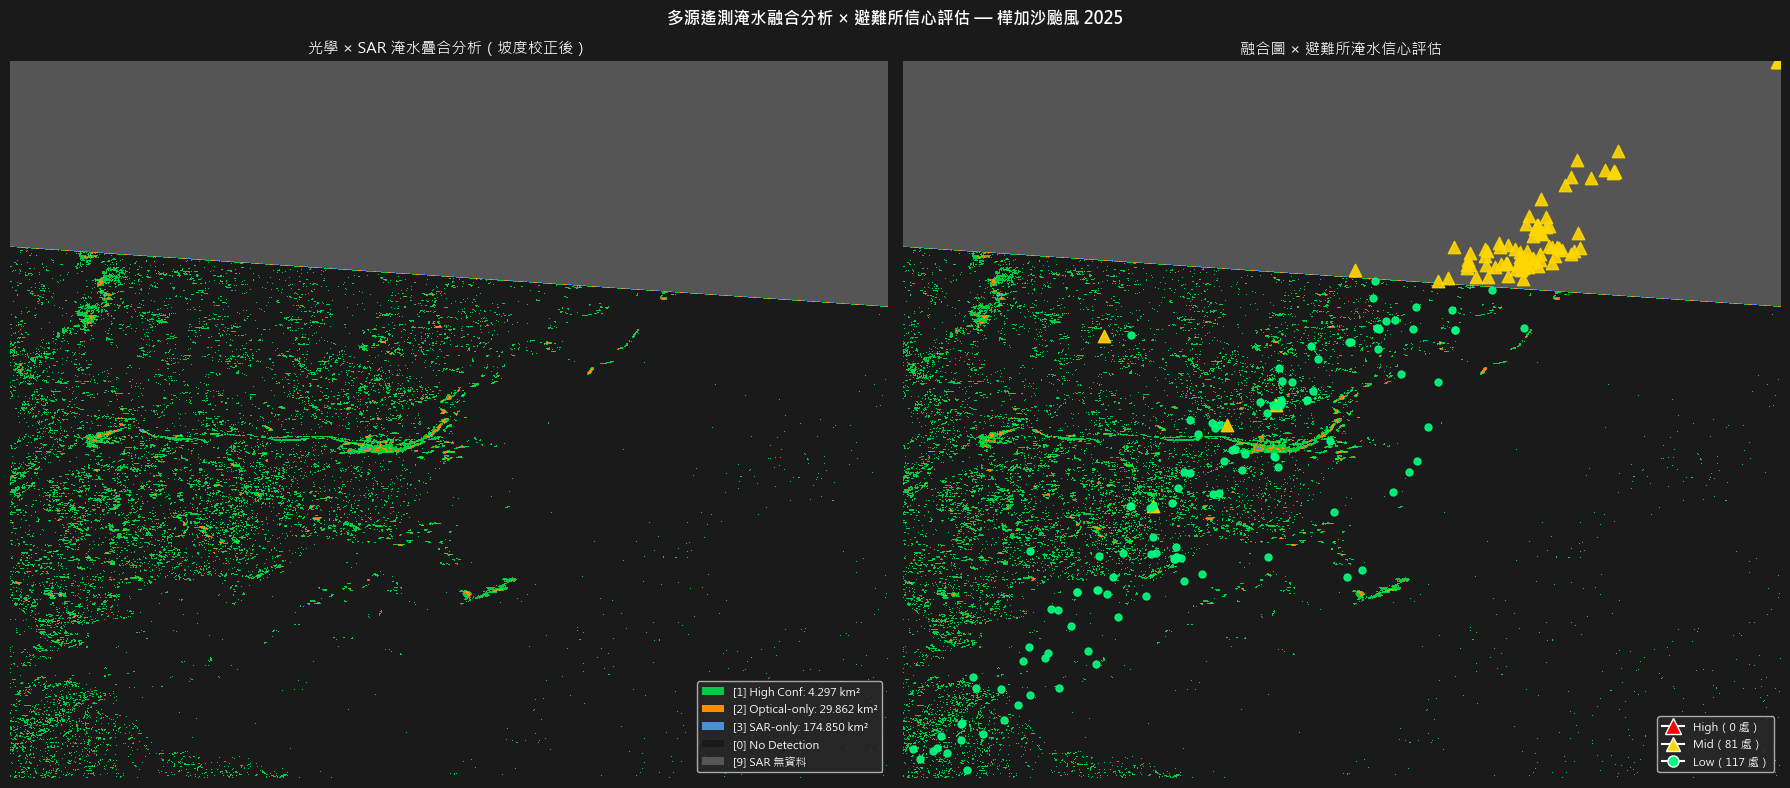

✅ 融合地圖已儲存: fusion_flood_shelter_map.png


In [23]:
# Cell 4F-4: 視覺化四分類融合圖 + Shelter 疊合
from pyproj import Transformer  # ← 移到最上面
import matplotlib.patches as mpatches
...
# Cell 4F-4: 視覺化四分類融合圖 + Shelter 疊合
# 0=皆無(深灰) 1=綠(高信心) 2=橘(光學) 3=藍(SAR) 9→4=中灰(無資料)

fusion_disp = np.where(fusion == 9, 4, fusion)
FUSION_COLORS = ['#1a1a1a', '#00CC44', '#FF8C00', '#4A90D9', '#555555']
FUSION_LABELS = ['No Detection', 'High Conf (光學+SAR)',
                 'Optical-only', 'SAR-only', 'SAR 無資料']
cmap_fusion = mcolors.ListedColormap(FUSION_COLORS)
norm_fusion = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], cmap_fusion.N)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), facecolor='#1a1a1a')

# ── 左圖：純四分類融合圖 ─────────────────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#1a1a1a')
ax1.imshow(fusion_disp, cmap=cmap_fusion, norm=norm_fusion, aspect='auto')
ax1.set_title('光學 × SAR 淹水疊合分析（坡度校正後）',
              fontsize=11, color='white', pad=6)
ax1.axis('off')
ax1.legend(handles=[
    Patch(facecolor=FUSION_COLORS[1], label=f'[1] High Conf: {area[1]:.3f} km²'),
    Patch(facecolor=FUSION_COLORS[2], label=f'[2] Optical-only: {area[2]:.3f} km²'),
    Patch(facecolor=FUSION_COLORS[3], label=f'[3] SAR-only: {area[3]:.3f} km²'),
    Patch(facecolor=FUSION_COLORS[0], label='[0] No Detection'),
    Patch(facecolor=FUSION_COLORS[4], label='[9] SAR 無資料'),
], loc='lower right', fontsize=8, facecolor='#2a2a2a', labelcolor='white')

# ── 右圖：融合圖 + Shelter ───────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#1a1a1a')
ax2.imshow(fusion_disp, cmap=cmap_fusion, norm=norm_fusion, aspect='auto')
ax2.set_title('融合圖 × 避難所淹水信心評估',
              fontsize=11, color='white', pad=6)
ax2.axis('off')


h_img, w_img = fusion.shape
from pyproj import Transformer
transformer = Transformer.from_crs('EPSG:4326', f'EPSG:{TARGET_EPSG}', always_xy=True)
utm_xmin, utm_ymin = transformer.transform(HUALIEN_BBOX[0], HUALIEN_BBOX[1])
utm_xmax, utm_ymax = transformer.transform(HUALIEN_BBOX[2], HUALIEN_BBOX[3])

for conf, color, marker, ms, label in [
    ('high', 'red',     '^', 150, 'High（光學+SAR）'),
    ('mid',  '#FFD700', '^',  80, 'Mid（單源淹水）'),
    ('low',  '#00FF7F', 'o',  25, 'Low（無淹水）'),
]:
    sub = shelters[shelters['flood_confidence'] == conf]
    if len(sub) == 0: continue
    xs = ((sub.geometry.x - utm_xmin) / (utm_xmax - utm_xmin) * w_img).values
    ys = ((utm_ymax - sub.geometry.y) / (utm_ymax - utm_ymin) * h_img).values
    ax2.scatter(xs, ys, c=color, marker=marker, s=ms,
                alpha=0.9, zorder=5, label=label)

ax2.legend(handles=[
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='red',
               ms=12, label=f'High（{counts.get("high",0)} 處）'),
    plt.Line2D([0],[0], marker='^', color='w', markerfacecolor='#FFD700',
               ms=10, label=f'Mid（{counts.get("mid",0)} 處）'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#00FF7F',
               ms=8,  label=f'Low（{counts.get("low",0)} 處）'),
], loc='lower right', fontsize=8, facecolor='#2a2a2a', labelcolor='white')

fig.patch.set_facecolor('#1a1a1a')
plt.suptitle('多源遙測淹水融合分析 × 避難所信心評估 — 樺加沙颱風 2025',
             fontsize=12, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'fusion_flood_shelter_map.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
plt.close()
print('✅ 融合地圖已儲存: fusion_flood_shelter_map.png')

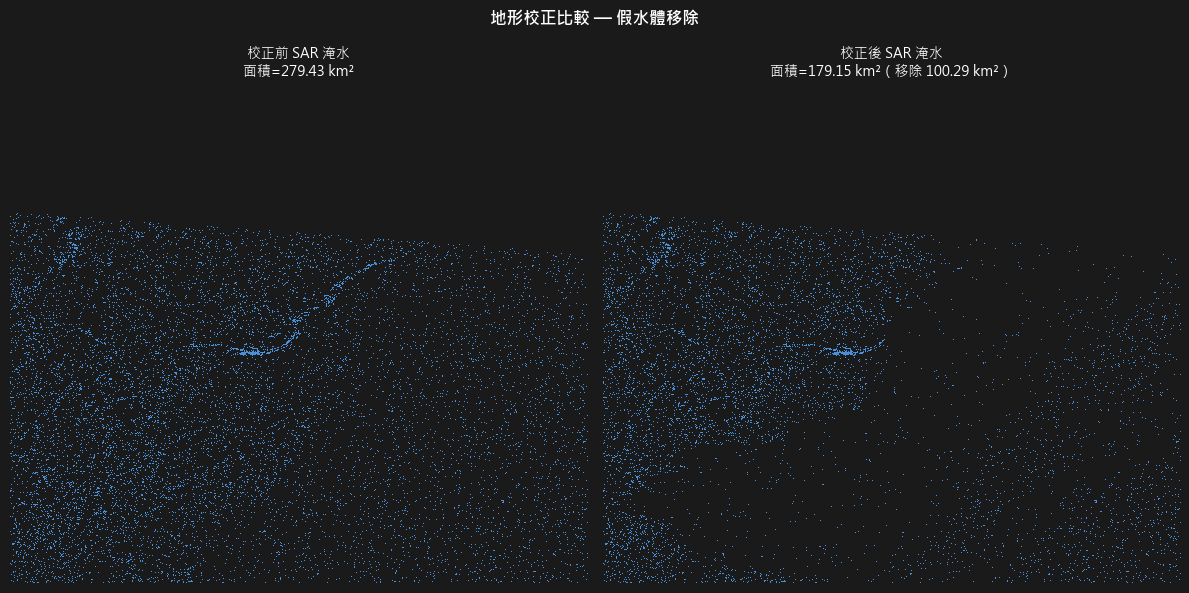

✅ 地形校正比較圖已儲存


In [24]:
# Cell 4F-5: 地形校正前後比較圖（兩欄）
fig, axes = plt.subplots(1, 2, figsize=(12, 6), facecolor='#1a1a1a')

cmap_binary = mcolors.ListedColormap(['#1a1a1a', '#4A90D9'])

for ax, (data, title) in zip(axes, [
    (sar_flood_mask,           f'校正前 SAR 淹水\n面積={sar_flood_mask.sum()*PIXEL_AREA_KM2:.2f} km²'),
    (sar_flood_mask_corrected, f'校正後 SAR 淹水\n面積={sar_flood_mask_corrected.sum()*PIXEL_AREA_KM2:.2f} km²（移除 {removed_area:.2f} km²）'),
]):
    ax.set_facecolor('#1a1a1a')
    ax.imshow(data, cmap=cmap_binary, vmin=0, vmax=1,
              aspect='auto', interpolation='none')
    ax.set_title(title, fontsize=10, color='white', pad=4)
    ax.axis('off')

fig.patch.set_facecolor('#1a1a1a')
plt.suptitle('地形校正比較 — 假水體移除', fontsize=12,
             fontweight='bold', color='white')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'topographic_correction.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
plt.close()
print('✅ 地形校正比較圖已儲存')

崩塌: 2302 個  光學水體: 1860 個  SAR淹水: 12917 個  High Conf: 211 個
✅ 土石流溪流: 186 條


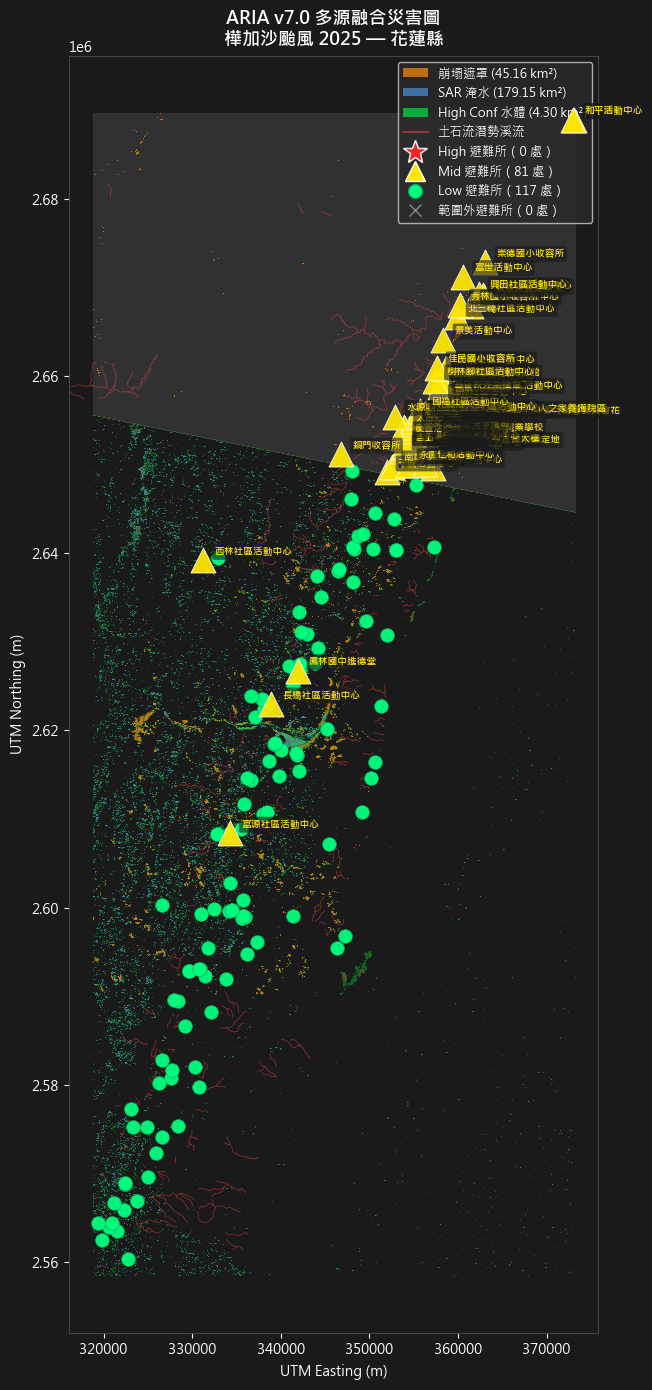

✅ ARIA v7.0 主圖已儲存


In [25]:
# Cell 4H: ARIA v7.0 綜合災害疊合主圖
from rasterio.features import shapes
from shapely.geometry import shape

extent = [_xmin, _xmax, _ymin, _ymax]

# ── 向量化各遮罩 ──────────────────────────────────────────────────────────────
def mask_to_gdf(mask_arr, epsg, min_area_m2=2000, label=''):
    from rasterio.transform import from_bounds as rb
    transform = rb(_xmin, _ymin, _xmax, _ymax,
                   mask_arr.shape[1], mask_arr.shape[0])
    geoms = [{'geometry': shape(s), 'area_m2': shape(s).area, 'label': label}
             for s, v in shapes(mask_arr.astype(np.uint8), transform=transform) if v == 1]
    if not geoms:
        return gpd.GeoDataFrame(columns=['geometry','area_m2','label'],
                                crs=f'EPSG:{epsg}')
    gdf = gpd.GeoDataFrame(geoms, crs=f'EPSG:{epsg}')
    return gdf[gdf.area_m2 >= min_area_m2].reset_index(drop=True)

landslide_gdf     = mask_to_gdf(landslide_mask,           TARGET_EPSG, label='landslide')
optical_water_gdf = mask_to_gdf(optical_water_mask,       TARGET_EPSG, label='optical_water')
sar_flood_gdf     = mask_to_gdf(sar_flood_mask_corrected, TARGET_EPSG, label='sar_flood')
hc_gdf            = mask_to_gdf((fusion==1).astype(np.uint8), TARGET_EPSG, label='high_conf')

print(f'崩塌: {len(landslide_gdf)} 個  '
      f'光學水體: {len(optical_water_gdf)} 個  '
      f'SAR淹水: {len(sar_flood_gdf)} 個  '
      f'High Conf: {len(hc_gdf)} 個')

# ── 載入土石流溪流 ────────────────────────────────────────────────────────────
COUNTY_COLS = ['COUNTYNAME','COUNTY','COUNTY_NAME','縣市名稱','CtyName']
try:
    debris_all = gpd.read_file(DEBRIS_SHP, encoding='utf-8')
    cc = next((c for c in COUNTY_COLS if c in debris_all.columns), None)
    if cc:
        debris_hualien = debris_all[
            debris_all[cc].str.contains('花蓮', na=False)
        ].to_crs(f'EPSG:{TARGET_EPSG}')
    else:
        tmp = debris_all.to_crs('EPSG:4326')
        debris_hualien = debris_all[
            tmp.geometry.intersects(box(*HUALIEN_BBOX))
        ].to_crs(f'EPSG:{TARGET_EPSG}')
    print(f'✅ 土石流溪流: {len(debris_hualien)} 條')
except Exception as e:
    print(f'❌ {e}'); debris_hualien = gpd.GeoDataFrame()

# ── 繪圖 ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 14), facecolor='#1a1a1a')
ax.set_facecolor('#1a1a1a')

# 底圖：fusion 圖（淡化）
cmap_fusion = mcolors.ListedColormap(['#1a1a1a','#00CC44','#FF8C00','#4A90D9','#555555'])
norm_fusion = mcolors.BoundaryNorm([-0.5,0.5,1.5,2.5,3.5,4.5], cmap_fusion.N)
ax.imshow(np.where(fusion==9, 4, fusion),
          cmap=cmap_fusion, norm=norm_fusion,
          extent=extent, origin='upper', aspect='auto', alpha=0.4)

# 崩塌遮罩（橘色）
if len(landslide_gdf) > 0:
    landslide_gdf.plot(ax=ax, color='#FF8C00', alpha=0.7)

# SAR 淹水（藍色）
if len(sar_flood_gdf) > 0:
    sar_flood_gdf.plot(ax=ax, color='#4A90D9', alpha=0.7)

# High Confidence 水體（綠色）
if len(hc_gdf) > 0:
    hc_gdf.plot(ax=ax, color='#00CC44', alpha=0.8)

# 土石流溪流（紅線）
if len(debris_hualien) > 0:
    debris_hualien.plot(ax=ax, color='#FF4444', linewidth=0.5, alpha=0.5)

# ── 避難所：三種信心度用不同顏色 + 形狀 ──────────────────────────────────────
SHELTER_STYLES = {
    'high':          {'color': '#FF2222', 'marker': '*',  's': 625, 'zorder': 7,
                      'edgecolor': 'white',   'linewidth': 0.8},
    'mid':           {'color': '#FFE600', 'marker': '^',  's': 324, 'zorder': 6,
                      'edgecolor': 'white',   'linewidth': 0.6},
    'low':           {'color': '#00FF7F', 'marker': 'o',  's': 100, 'zorder': 5,
                      'edgecolor': '#00AA55', 'linewidth': 0.4},
    'out_of_extent': {'color': '#888888', 'marker': 'x',  's': 64,  'zorder': 4,
                      'edgecolor': '#888888', 'linewidth': 0.4},
}

if len(shelters) > 0:
    for conf, style in SHELTER_STYLES.items():
        sub = shelters[shelters['flood_confidence'] == conf]
        if len(sub) == 0: continue
        ax.scatter(
            sub.geometry.x, sub.geometry.y,
            c=style['color'],
            marker=style['marker'],
            s=style['s'],
            edgecolors=style['edgecolor'],
            linewidths=style['linewidth'],
            alpha=0.95,
            zorder=style['zorder'],
        )

    # mid 避難所加文字標籤（兩個鳳林的點很近，標籤幫助區分）
    mid_sub = shelters[shelters['flood_confidence'] == 'mid']
    for _, row in mid_sub.iterrows():
        ax.annotate(
            row['避難收容處所名稱'],
            xy=(row.geometry.x, row.geometry.y),
            xytext=(8, 4),
            textcoords='offset points',
            fontsize=7,
            color='#FFE600',
            fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#1a1a1a',
                      alpha=0.6, edgecolor='none'),
            zorder=8
        )

# ── 圖例 ──────────────────────────────────────────────────────────────────────
legend_elems = [
    Patch(facecolor='#FF8C00', alpha=0.7,
          label=f'崩塌遮罩 ({landslide_area:.2f} km²)'),
    Patch(facecolor='#4A90D9', alpha=0.7,
          label=f'SAR 淹水 ({sar_flood_mask_corrected.sum()*PIXEL_AREA_KM2:.2f} km²)'),
    Patch(facecolor='#00CC44', alpha=0.8,
          label=f'High Conf 水體 ({area[1]:.2f} km²)'),
    plt.Line2D([0],[0], color='#FF4444', lw=1.2,
               alpha=0.6, label='土石流潛勢溪流'),
    plt.Line2D([0],[0], marker='*', color='w', linestyle='None',
               markerfacecolor='#FF2222', markeredgecolor='white',
               ms=18, label=f'High 避難所（{counts.get("high",0)} 處）'),
    plt.Line2D([0],[0], marker='^', color='w', linestyle='None',
               markerfacecolor='#FFE600', markeredgecolor='white',
               ms=14, label=f'Mid 避難所（{counts.get("mid",0)} 處）'),
    plt.Line2D([0],[0], marker='o', color='w', linestyle='None',
               markerfacecolor='#00FF7F', markeredgecolor='#00AA55',
               ms=10, label=f'Low 避難所（{counts.get("low",0)} 處）'),
    plt.Line2D([0],[0], marker='x', color='#888888', linestyle='None',
               ms=8, label=f'範圍外避難所（{counts.get("out_of_extent",0)} 處）'),
]
ax.legend(handles=legend_elems, loc='upper right',
          fontsize=9, facecolor='#2a2a2a', labelcolor='white')

# 涵蓋所有避難所（含範圍外）
all_x = shelters.geometry.x
all_y = shelters.geometry.y

pad_x = (all_x.max() - all_x.min()) * 0.05
pad_y = (all_y.max() - all_y.min()) * 0.05

ax.set_xlim(min(_xmin, all_x.min()) - pad_x,
            max(_xmax, all_x.max()) + pad_x)
ax.set_ylim(min(_ymin, all_y.min()) - pad_y,
            max(_ymax, all_y.max()) + pad_y)

ax.set_title('ARIA v7.0 多源融合災害圖\n樺加沙颱風 2025 — 花蓮縣',
             fontsize=13, fontweight='bold', color='white', pad=8)
ax.set_xlabel('UTM Easting (m)', color='white')
ax.set_ylabel('UTM Northing (m)', color='white')
ax.tick_params(colors='white')
for sp in ax.spines.values():
    sp.set_edgecolor('#444')

fig.patch.set_facecolor('#1a1a1a')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'aria_v7_final_map.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()
plt.close()
print('✅ ARIA v7.0 主圖已儲存')

In [26]:
# Cell: 輸出 30m 網格 GPKG（fusion_class + 災後 NDVI/NDWI）
import numpy as np
import geopandas as gpd
from shapely.geometry import box
from rasterio.transform import from_bounds as rio_bounds
from rasterio.enums import Resampling
import rasterio.warp

GRID_RES = 30

# ── 影像範圍 ──────────────────────────────────────────────────────────────────
_x = pre_reflect.x.values
_y = pre_reflect.y.values
xmin, xmax = float(_x.min()), float(_x.max())
ymin, ymax = float(_y.min()), float(_y.max())

nx = int((xmax - xmin) / GRID_RES)
ny = int((ymax - ymin) / GRID_RES)
transform_30m = rio_bounds(xmin, ymin, xmax, ymax, nx, ny)

# ── Resample 函式 ─────────────────────────────────────────────────────────────
def resample_to_30m(arr, method=Resampling.nearest):
    src_h, src_w = arr.shape
    src_transform = rio_bounds(xmin, ymin, xmax, ymax, src_w, src_h)
    dst = np.empty((ny, nx), dtype='float32')
    rasterio.warp.reproject(
        source=arr.astype('float32'),
        destination=dst,
        src_transform=src_transform,
        src_crs=f'EPSG:{TARGET_EPSG}',
        dst_transform=transform_30m,
        dst_crs=f'EPSG:{TARGET_EPSG}',
        resampling=method,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst

# ── Resample ──────────────────────────────────────────────────────────────────
print('Resampling...')
r_ndvi_post    = resample_to_30m(ndvi_post,  Resampling.average)
r_ndwi_post    = resample_to_30m(ndwi_post,  Resampling.average)
r_fusion       = resample_to_30m(fusion.astype('float32'), Resampling.nearest)
print(f'✅ 完成，網格: {ny} × {nx} = {ny*nx:,} pixels')

# ── 建立 GeoDataFrame ─────────────────────────────────────────────────────────
print('建立 GeoDataFrame...')
rows, cols = np.mgrid[0:ny, 0:nx]
xs = xmin + cols.ravel() * GRID_RES
ys = ymax - (rows.ravel() + 1) * GRID_RES

# fusion_class label 對照
def fusion_to_label(v):
    m = {0: '無淹水', 1: '兩者皆有淹水', 2: '僅光學偵測',
         3: '僅SAR偵測', 9: '無淹水(SAR無資料)', -1: '無淹水(範圍外)'}
    return m.get(int(v), 'unknown')

fc = r_fusion.ravel().astype('int8')

gdf = gpd.GeoDataFrame({
    'geometry':      [box(x, y, x+GRID_RES, y+GRID_RES) for x, y in zip(xs, ys)],
    'ndvi_post':     r_ndvi_post.ravel(),
    'ndwi_post':     r_ndwi_post.ravel(),
    'fusion_class':  fc,
    'fusion_label':  [fusion_to_label(v) for v in fc],
}, crs=f'EPSG:{TARGET_EPSG}')

# 移除全 NaN pixel
gdf = gdf.dropna(subset=['ndvi_post', 'ndwi_post'], how='all').reset_index(drop=True)
print(f'有效 pixel 數: {len(gdf):,}')

# ── 輸出 GPKG ─────────────────────────────────────────────────────────────────
out_gpkg = OUTPUT_DIR / 'risk_grid_30m.gpkg'
gdf.to_file(out_gpkg, layer='risk_grid', driver='GPKG')
print(f'✅ {out_gpkg.name}  ({out_gpkg.stat().st_size/1e6:.1f} MB)')

Resampling...
✅ 完成，網格: 4374 × 1813 = 7,930,062 pixels
建立 GeoDataFrame...
有效 pixel 數: 5,631,246
✅ risk_grid_30m.gpkg  (1568.5 MB)
